# 1. Data & Configuration

This section initializes the modelling environment, defines the project
configuration and loads the encoded development and test datasets prepared
during the upstream PD data pipeline.

The development sample is used for model training, internal validation and
hyperparameter tuning. The external test sample remains reserved for the final
out-of-sample evaluation.

The modelling datasets are validated for feature consistency, sample alignment
and missing values before model development begins.

In [1]:
# =============================================================================
# Imports and Configuration
# =============================================================================

import sys
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from imblearn.over_sampling import RandomOverSampler

from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.ensemble import (
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

from matplotlib.ticker import PercentFormatter


# Project root
CURRENT_DIR = Path.cwd().resolve()

PROJECT_ROOT = (
    CURRENT_DIR.parent
    if CURRENT_DIR.name == "notebooks"
    else CURRENT_DIR
)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


# Project modules
from src.config import (
    RANDOM_STATE,
    VALIDATION_SIZE,
    MAX_ITER,
)



from src.evaluation import evaluate_pd_model

from src.preprocessing import (
    build_logistic_preprocessor,
)

from src.artifacts import (
    save_model_artifacts,
    load_model_artifacts,
    save_final_pd_artifacts,
)

In [2]:
# =============================================================================
# Project Paths
# =============================================================================

PD_DATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "pd"
)

MODEL_DIR = (
    PROJECT_ROOT
    / "models"
    / "pd"
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

In [3]:
# =============================================================================
# Load Modelling Datasets
# =============================================================================

X_train_encoded = pd.read_parquet(
    PD_DATA_DIR / "pd_X_train_encoded.parquet"
)

X_test_encoded = pd.read_parquet(
    PD_DATA_DIR / "pd_X_test_encoded.parquet"
)

y_train = (
    pd.read_parquet(
        PD_DATA_DIR / "pd_y_train.parquet"
    )
    .squeeze("columns")
)

y_test = (
    pd.read_parquet(
        PD_DATA_DIR / "pd_y_test.parquet"
    )
    .squeeze("columns")
)

In [4]:
# =============================================================================
# Initial Validation
# =============================================================================

assert X_train_encoded.columns.equals(
    X_test_encoded.columns
)

assert len(X_train_encoded) == len(y_train)
assert len(X_test_encoded) == len(y_test)

assert not X_train_encoded.isna().any().any()
assert not X_test_encoded.isna().any().any()


dataset_summary = pd.DataFrame(
    {
        "Dataset": ["Development", "Test"],
        "Rows": [
            len(X_train_encoded),
            len(X_test_encoded),
        ],
        "Features": [
            X_train_encoded.shape[1],
            X_test_encoded.shape[1],
        ],
        "Default Rate": [
            y_train.mean(),
            y_test.mean(),
        ],
    }
)

display(
    dataset_summary.style.format({
        "Default Rate": "{:.2%}",
    })
)

,Dataset,Rows,Features,Default Rate
0,Development,373028,95,10.93%
1,Test,93257,95,10.93%


# 2. Modelling Framework

The PD modelling process follows a benchmark-and-challenger framework.

The development sample is divided into two subsets:

- **Fit sample (`X_fit`, `y_fit`)**: used for baseline estimation and
  cross-validated hyperparameter tuning;
- **Validation sample (`X_val`, `y_val`)**: retained as a common internal
  holdout for model comparison and champion selection.

The external test sample remains untouched throughout model development and is
used only once for the final out-of-sample evaluation of the selected champion.

Logistic regression serves as the benchmark model, while nonlinear tree-based
models are evaluated as challengers under the same validation framework.

Model selection considers both discrimination and probability quality:

- **ROC-AUC, Gini and KS** for discriminatory performance;
- **Brier Score and Log Loss** for probability accuracy;
- **Calibration** between predicted PD and observed default rates.

Threshold-dependent metrics such as accuracy, precision, recall and F1-score
are treated as secondary diagnostics and are not used as the primary criteria
for selecting the PD model.

After champion selection, the model specification is frozen, refitted on the
complete development sample and evaluated once on the untouched test sample.

## Evaluation Metrics

The PD models are evaluated using complementary metrics that assess
discrimination, probability quality and calibration.

### ROC-AUC, Gini and Kolmogorov-Smirnov

ROC-AUC measures the model's ability to discriminate between borrowers who
default and those who do not.

The Gini coefficient is derived from ROC-AUC:

$$
\text{Gini} = 2 \times \text{ROC-AUC} - 1
$$

The Kolmogorov-Smirnov (KS) statistic measures the maximum separation between
the cumulative distributions of predicted risk for defaulting and
non-defaulting borrowers:

$$
KS =
\max_t
\left|
F_{0}(t)-F_{1}(t)
\right|
$$

where $F_{0}(t)$ and $F_{1}(t)$ represent the cumulative distributions for
non-defaulting and defaulting borrowers, respectively.

Higher ROC-AUC, Gini and KS values indicate stronger discriminatory power.

### Log Loss

Log Loss evaluates the quality of predicted probabilities and penalizes
confident but incorrect predictions:

$$
\text{Log Loss}
=
-\frac{1}{N}
\sum_{i=1}^{N}
\left[
y_i \log(p_i)
+
(1-y_i)\log(1-p_i)
\right]
$$

Lower values indicate better probabilistic performance.

### Brier Score

The Brier Score measures the mean squared difference between predicted
probabilities and observed outcomes:

$$
BS = \frac{1}{N}
\sum_{i=1}^{N}
(p_i-y_i)^2
$$

Lower values indicate better probability estimates.

### Calibration

Calibration assesses whether predicted probabilities correspond to observed
default frequencies.

A well-calibrated PD model should satisfy approximately:

$$
P\left(Y=1 \mid \widehat{PD}=p\right) \approx p
$$

For example, among borrowers assigned a predicted PD close to $10\%$, the
observed default rate should also be approximately $10\%$.

Calibration is assessed using the mean predicted PD, the observed default rate,
and calibration curves.

# 3. Logistic Regression Baseline

Logistic regression is used as the initial benchmark for Probability of Default
(PD) modelling.

Three training strategies are compared to assess the impact of class imbalance:

- **Original:** logistic regression trained on the observed class distribution;
- **Class Weight:** logistic regression using balanced class weights;
- **Random Oversampling:** logistic regression trained after randomly
  oversampling the minority class within the fit sample.

All three models use the same feature representation, preprocessing procedure
and logistic-regression specification so that differences in performance can
be attributed primarily to the class-imbalance treatment.

The comparison focuses on discrimination, probability quality and calibration.
The internal validation sample is used exclusively for model comparison, while
the external test sample remains untouched.

## 3.1 Development Split and Preprocessing

The development sample is divided into stratified fit and validation subsets.

The fit sample is used to estimate preprocessing parameters and model
coefficients, while the validation sample provides a common out-of-sample
benchmark for comparing the baseline training strategies.

Random oversampling is applied exclusively to the fit sample. The validation
sample remains unchanged and therefore preserves the observed default
distribution.

For logistic regression, quantitative variables are standardized within the
modelling pipeline, while binary and ordinal-encoded variables are left
unchanged.

In [5]:
# =============================================================================
# 3.1 Development Split and Preprocessing
# =============================================================================

# Internal development split
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train_encoded,
    y_train,
    test_size=VALIDATION_SIZE,
    stratify=y_train,
    random_state=RANDOM_STATE,
)

# Logistic regression preprocessing
ordinal_features = [
    "sub_grade",
    "emp_length_years",
]

(
    logistic_preprocessor,
    numeric_features,
    ordinal_features,
    binary_features,
) = build_logistic_preprocessor(
    X=X_fit,
    ordinal_features=ordinal_features,
)

# Random oversampling
random_oversampler = RandomOverSampler(
    random_state=RANDOM_STATE
)

X_fit_over, y_fit_over = random_oversampler.fit_resample(
    X_fit,
    y_fit,
)

# Development data summary
development_summary = pd.DataFrame(
    {
        "Sample": [
            "Fit",
            "Validation",
            "Oversampled Fit",
        ],
        "Rows": [
            len(y_fit),
            len(y_val),
            len(y_fit_over),
        ],
        "Defaults": [
            y_fit.sum(),
            y_val.sum(),
            y_fit_over.sum(),
        ],
        "Non-Defaults": [
            len(y_fit) - y_fit.sum(),
            len(y_val) - y_val.sum(),
            len(y_fit_over) - y_fit_over.sum(),
        ],
        "Default Rate": [
            y_fit.mean(),
            y_val.mean(),
            y_fit_over.mean(),
        ],
    }
)

display(
    development_summary.style.format({
        "Default Rate": "{:.2%}",
    })
)

print(
    f"Features: {len(X_fit.columns)} total | "
    f"{len(numeric_features)} quantitative | "
    f"{len(ordinal_features)} ordinal | "
    f"{len(binary_features)} binary"
)

,Sample,Rows,Defaults,Non-Defaults,Default Rate
0,Fit,298422,32619,265803,10.93%
1,Validation,74606,8155,66451,10.93%
2,Oversampled Fit,531606,265803,265803,50.00%


Features: 95 total | 28 quantitative | 2 ordinal | 65 binary


## 3.2 Baseline Training Strategies

Three logistic-regression baselines are trained using the same feature
representation and preprocessing specification.

The models differ only in their treatment of class imbalance:

- the observed class distribution;
- balanced class weights;
- random oversampling of the fit sample.

All models are evaluated on the same untouched validation sample.

In [6]:
# =============================================================================
# 3.2 Baseline Training Strategies
# =============================================================================

baseline_results = []
baseline_models = {}

baseline_strategies = {
    "Original": {
        "X": X_fit,
        "y": y_fit,
        "class_weight": None,
    },
    "Class Weight": {
        "X": X_fit,
        "y": y_fit,
        "class_weight": "balanced",
    },
    "Random Oversampling": {
        "X": X_fit_over,
        "y": y_fit_over,
        "class_weight": None,
    },
}

for strategy_name, strategy in baseline_strategies.items():

    model = Pipeline(
        steps=[
            (
                "preprocessor",
                logistic_preprocessor,
            ),
            (
                "model",
                LogisticRegression(
                    solver="liblinear",
                    class_weight=strategy["class_weight"],
                    max_iter=MAX_ITER,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )

    model.fit(
        strategy["X"],
        strategy["y"],
    )

    results = evaluate_pd_model(
        model=model,
        X=X_val,
        y=y_val,
    )

    results.insert(
        0,
        "Training Strategy",
        strategy_name,
    )

    baseline_results.append(results)
    baseline_models[strategy_name] = model

## 3.3 Baseline Results 

The three training strategies are evaluated on the same untouched validation
sample.

ROC-AUC, Gini and KS measure discriminatory performance, while Brier Score and
Log Loss assess the quality of the estimated default probabilities. Particular
attention is also given to the relationship between the mean predicted PD and
the observed validation default rate.

Calibration curves provide an additional diagnostic of how closely predicted
probabilities correspond to observed default frequencies.

In [7]:
# =============================================================================
# 3.3 Baseline Results 
# =============================================================================

baseline_comparison = (
    pd.concat(
        baseline_results,
        ignore_index=True
    )
    .sort_values(
        "ROC-AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    baseline_comparison.round(4)
)

,Training Strategy,ROC-AUC,Gini,KS,Mean Predicted PD,Observed Default Rate,Brier Score,Log Loss
0,Class Weight,0.6930,0.3859,0.2828,0.4576,0.1093,0.2234,0.6377
1,Original,0.6928,0.3855,0.2816,0.1094,0.1093,0.0927,0.3220
2,Random Oversampling,0.6928,0.3855,0.2817,0.4575,0.1093,0.2234,0.6376


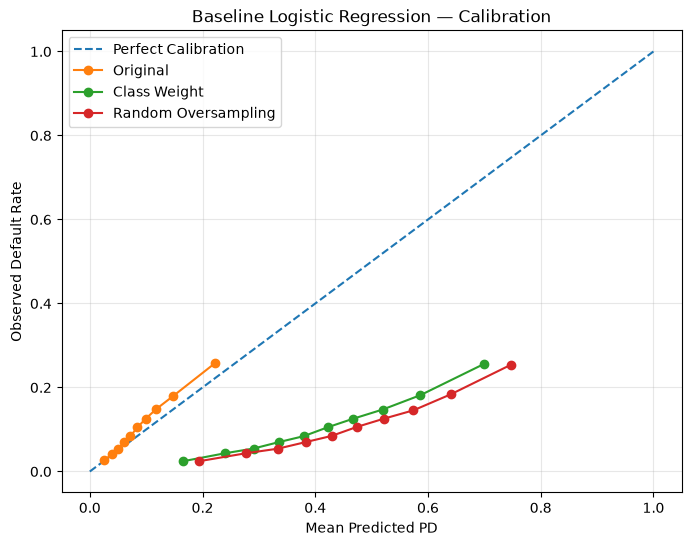

In [8]:
# -----------------------------------------------------------------------------
# Baseline calibration
# -----------------------------------------------------------------------------

plt.figure(
    figsize=(8, 6)
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

for model_name, model in baseline_models.items():

    y_val_proba = (
        model.predict_proba(
            X_val
        )[:, 1]
    )

    observed_rate, predicted_pd = (
        calibration_curve(
            y_val,
            y_val_proba,
            n_bins=10,
            strategy="quantile"
        )
    )

    plt.plot(
        predicted_pd,
        observed_rate,
        marker="o",
        label=model_name
    )

plt.xlabel(
    "Mean Predicted PD"
)

plt.ylabel(
    "Observed Default Rate"
)

plt.title(
    "Baseline Logistic Regression — Calibration"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()

## 3.4 Baseline Interpretation and Decision

The three strategies achieve nearly identical discriminatory performance
(ROC-AUC ≈ 0.693). However, class weighting and random oversampling strongly
inflate predicted default probabilities relative to the observed validation
default rate.

The original strategy maintains comparable discrimination while providing
substantially better probability quality and calibration.

**Decision:** the original class distribution is retained for subsequent
logistic-regression tuning.

# 4. Logistic Regression Tuning

The baseline analysis retained the original class distribution for PD modelling.

The logistic regression benchmark is tuned by comparing L1 and L2
regularization across a compact range of regularization strengths.

Hyperparameters are selected using stratified 5-fold cross-validation on the
fit sample only. Preprocessing remains embedded within the modelling pipeline
to prevent data leakage.

The validation sample is excluded from hyperparameter selection and is used
only to assess the selected logistic configuration.

## 4.1 Search Setup

Hyperparameter tuning is performed using stratified 5-fold cross-validation
on the fit sample.

L1 and L2 regularization are compared across a compact range of `C` values.
ROC-AUC is used as the primary model-selection criterion, while Brier Score
and Log Loss are monitored to assess probability quality.

In [9]:
# =============================================================================
# 4.1 Search Setup
# =============================================================================

# Stratified cross-validation
cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)


# Logistic regression pipeline
logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            logistic_preprocessor,
        ),
        (
            "model",
            LogisticRegression(
                solver="liblinear",
                max_iter=MAX_ITER,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)


# Hyperparameter search space
C_VALUES = [
    0.05,
    0.10,
    0.25,
    0.50,
    1.00,
]

logistic_param_grid = [
    {
        "model__penalty": ["l1"],
        "model__C": C_VALUES,
    },
    {
        "model__penalty": ["l2"],
        "model__C": C_VALUES,
    },
]


# Search size
n_folds = cv_strategy.get_n_splits()

n_configurations = (
    len(C_VALUES)
    * 2
)

n_cv_fits = (
    n_configurations
    * n_folds
)


print("Logistic Regression Grid Search")
print("=" * 60)
print(f"Regularization types : L1, L2")
print(f"C values             : {C_VALUES}")
print(f"Configurations       : {n_configurations}")
print(f"CV folds             : {n_folds}")
print(f"Total CV fits        : {n_cv_fits}")

Logistic Regression Grid Search
Regularization types : L1, L2
C values             : [0.05, 0.1, 0.25, 0.5, 1.0]
Configurations       : 10
CV folds             : 5
Total CV fits        : 50


## 4.2 Grid Search and Cross-Validation Results

The hyperparameter search evaluates each combination of regularization type and
regularization strength using the same cross-validation folds.

ROC-AUC is used as the primary selection criterion, while Brier Score and Log
Loss are monitored to assess the quality of the estimated default probabilities.
Train and validation ROC-AUC are also compared to identify potential
overfitting.

In [10]:
# =============================================================================
# 4.2 Grid Search and Cross-Validation Results
# =============================================================================

logistic_grid_search = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=logistic_param_grid,
    scoring={
        "roc_auc": "roc_auc",
        "neg_brier": "neg_brier_score",
        "neg_log_loss": "neg_log_loss",
    },
    cv=cv_strategy,
    n_jobs=2,
    refit="roc_auc",
    return_train_score=True,
    verbose=1,
)

print(
    f"Training: Logistic Regression GridSearchCV "
    f"({n_configurations} configurations × "
    f"{n_folds} folds = {n_cv_fits} fits)..."
)

start_time = perf_counter()

logistic_grid_search.fit(
    X_fit,
    y_fit,
)

elapsed_time = (
    perf_counter()
    - start_time
)

print(
    f"Completed in {elapsed_time:.1f} s"
)

Training: Logistic Regression GridSearchCV (10 configurations × 5 folds = 50 fits)...
Fitting 5 folds for each of 10 candidates, totalling 50 fits


c:\Users\htouy\OneDrive - HEC Montréal\Bureau\GitHub\risk-credit-scoring-new\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\htouy\OneDrive - HEC Montréal\Bureau\GitHub\risk-credit-scoring-new\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Completed in 1721.9 s


In [11]:
# -----------------------------------------------------------------------------
# Best configuration
# -----------------------------------------------------------------------------

best_logistic_model = (
    logistic_grid_search.best_estimator_
)

best_logistic_params = (
    logistic_grid_search.best_params_
)

best_index = (
    logistic_grid_search.best_index_
)

best_C = (
    best_logistic_params[
        "model__C"
    ]
)

best_regularization = (
    best_logistic_params[
        "model__penalty"
    ]
    .upper()
)

best_cv_auc = (
    logistic_grid_search.cv_results_[
        "mean_test_roc_auc"
    ][best_index]
)

best_cv_brier = -(
    logistic_grid_search.cv_results_[
        "mean_test_neg_brier"
    ][best_index]
)

best_cv_log_loss = -(
    logistic_grid_search.cv_results_[
        "mean_test_neg_log_loss"
    ][best_index]
)

print("BEST LOGISTIC REGRESSION")
print("=" * 60)
print(f"Regularization : {best_regularization}")
print(f"Best C         : {best_C}")
print(f"CV ROC-AUC     : {best_cv_auc:.4f}")
print(f"CV Brier Score : {best_cv_brier:.4f}")
print(f"CV Log Loss    : {best_cv_log_loss:.4f}")
print("=" * 60)

BEST LOGISTIC REGRESSION
Regularization : L1
Best C         : 0.5
CV ROC-AUC     : 0.6888
CV Brier Score : 0.0931
CV Log Loss    : 0.3234


In [12]:
# -----------------------------------------------------------------------------
# Cross-validation results
# -----------------------------------------------------------------------------

logistic_cv_raw = pd.DataFrame(
    logistic_grid_search.cv_results_
)

logistic_cv_results = pd.DataFrame(
    {
        "Regularization": (
            logistic_cv_raw[
                "param_model__penalty"
            ]
            .astype(str)
            .str.upper()
        ),
        "C": (
            logistic_cv_raw[
                "param_model__C"
            ]
            .astype(float)
        ),
        "Train ROC-AUC": (
            logistic_cv_raw[
                "mean_train_roc_auc"
            ]
        ),
        "CV ROC-AUC": (
            logistic_cv_raw[
                "mean_test_roc_auc"
            ]
        ),
        "CV ROC-AUC Std": (
            logistic_cv_raw[
                "std_test_roc_auc"
            ]
        ),
        "Brier Score": -(
            logistic_cv_raw[
                "mean_test_neg_brier"
            ]
        ),
        "Log Loss": -(
            logistic_cv_raw[
                "mean_test_neg_log_loss"
            ]
        ),
        "Rank": (
            logistic_cv_raw[
                "rank_test_roc_auc"
            ]
        ),
    }
)

logistic_cv_results["AUC Gap"] = (
    logistic_cv_results["Train ROC-AUC"]
    - logistic_cv_results["CV ROC-AUC"]
)

logistic_cv_results = (
    logistic_cv_results
    .sort_values(
        [
            "Rank",
            "Brier Score",
        ]
    )
    .reset_index(drop=True)
)

display(
    logistic_cv_results.round(4)
)

,Regularization,C,Train ROC-AUC,CV ROC-AUC,CV ROC-AUC Std,Brier Score,Log Loss,Rank,AUC Gap
0,L1,0.50,0.6901,0.6888,0.0013,0.0931,0.3234,1,0.0012
1,L1,0.25,0.6900,0.6888,0.0014,0.0931,0.3234,2,0.0012
2,L2,0.25,0.6901,0.6888,0.0013,0.0931,0.3234,3,0.0012
3,L1,1.00,0.6901,0.6888,0.0013,0.0931,0.3234,4,0.0012
4,L2,0.10,0.6900,0.6888,0.0013,0.0931,0.3234,5,0.0012
5,L2,0.05,0.6900,0.6888,0.0013,0.0931,0.3234,6,0.0012
6,L2,0.50,0.6901,0.6888,0.0013,0.0931,0.3234,7,0.0012
7,L2,1.00,0.6901,0.6888,0.0013,0.0931,0.3234,8,0.0013
8,L1,0.10,0.6898,0.6887,0.0014,0.0931,0.3234,9,0.0011
9,L1,0.05,0.6894,0.6884,0.0014,0.0931,0.3235,10,0.0009


## 4.3 Validation and Calibration

After hyperparameter selection, the best logistic regression configuration is
evaluated on the internal validation sample, which was not used during the
cross-validation search.

Performance is assessed using discrimination and probability-quality metrics.
The calibration curve additionally compares predicted PDs with observed default
rates across probability groups.

In [13]:
tuned_logistic_validation_results = (
    evaluate_pd_model(
        model=best_logistic_model,
        X=X_val,
        y=y_val
    )
)

tuned_logistic_validation_results.insert(
    0,
    "Model",
    (
        f"Tuned Logistic - "
        f"{best_regularization} "
        f"(C={best_C})"
    )
)

display(
    tuned_logistic_validation_results.round(4)
)

,Model,ROC-AUC,Gini,KS,Mean Predicted PD,Observed Default Rate,Brier Score,Log Loss
0,Tuned Logistic - L1 (C=0.5),0.6927,0.3854,0.2819,0.1094,0.1093,0.0927,0.3221


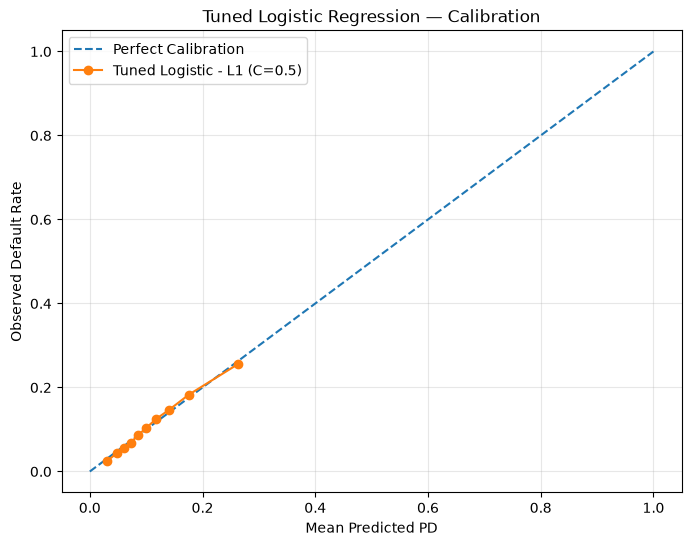

In [14]:
# -----------------------------------------------------------------------------
# Calibration
# -----------------------------------------------------------------------------

y_val_proba_tuned = (
    best_logistic_model.predict_proba(
        X_val
    )[:, 1]
)

observed_rate, predicted_pd = (
    calibration_curve(
        y_val,
        y_val_proba_tuned,
        n_bins=10,
        strategy="quantile"
    )
)

plt.figure(
    figsize=(8, 6)
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.plot(
    predicted_pd,
    observed_rate,
    marker="o",
    label=(
        f"Tuned Logistic - "
        f"{best_regularization} "
        f"(C={best_C})"
    )
)

plt.xlabel(
    "Mean Predicted PD"
)

plt.ylabel(
    "Observed Default Rate"
)

plt.title(
    "Tuned Logistic Regression — Calibration"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()

In [15]:

# -----------------------------------------------------------------------------
# Save artifacts
# -----------------------------------------------------------------------------

save_model_artifacts(
    best_model=best_logistic_model,
    best_params=best_logistic_params,
    cv_results=logistic_cv_results,
    model_name="logistic_regression",
    model_dir=MODEL_DIR,
)

## 5.1 Decision Tree

A Decision Tree is evaluated as the first nonlinear challenger to the tuned
logistic regression benchmark.

The model is trained directly on the encoded features without standardization.
Tree complexity is controlled through maximum depth, minimum leaf size and
minimum split size to limit overfitting.

Hyperparameters are selected using the same stratified cross-validation
framework and ROC-AUC criterion used for logistic regression. The selected tree
is then evaluated on the untouched internal validation sample.

In [16]:
# =============================================================================
# 5.1 Decision Tree
# =============================================================================

# -----------------------------------------------------------------------------
# Model and hyperparameter grid
# -----------------------------------------------------------------------------

decision_tree = DecisionTreeClassifier(
    random_state=RANDOM_STATE
)

decision_tree_param_grid = {
    "max_depth": [
        3,
        5,
        7,
        10,
    ],
    "min_samples_leaf": [
        100,
        500,
        1000,
    ],
    "min_samples_split": [
        200,
        1000,
    ],
}


# -----------------------------------------------------------------------------
# Search size
# -----------------------------------------------------------------------------

n_tree_configurations = (
    len(decision_tree_param_grid["max_depth"])
    * len(decision_tree_param_grid["min_samples_leaf"])
    * len(decision_tree_param_grid["min_samples_split"])
)

n_tree_cv_fits = (
    n_tree_configurations
    * n_folds
)

print("Decision Tree Grid Search")
print("=" * 60)
print(f"Configurations : {n_tree_configurations}")
print(f"CV folds       : {n_folds}")
print(f"Total CV fits  : {n_tree_cv_fits}")

Decision Tree Grid Search
Configurations : 24
CV folds       : 5
Total CV fits  : 120


In [17]:
# -----------------------------------------------------------------------------
# Grid search
# -----------------------------------------------------------------------------

decision_tree_grid_search = GridSearchCV(
    estimator=decision_tree,
    param_grid=decision_tree_param_grid,
    scoring={
        "roc_auc": "roc_auc",
        "neg_brier": "neg_brier_score",
        "neg_log_loss": "neg_log_loss",
    },
    cv=cv_strategy,
    n_jobs=1,
    refit="roc_auc",
    return_train_score=True,
    verbose=1,
)

print(
    f"Training: Decision Tree GridSearchCV "
    f"({n_tree_configurations} configurations × "
    f"{n_folds} folds = {n_tree_cv_fits} fits)..."
)

start_time = perf_counter()

decision_tree_grid_search.fit(
    X_fit,
    y_fit,
)

elapsed_time = (
    perf_counter()
    - start_time
)

print(
    f"Completed in {elapsed_time:.1f} s"
)

Training: Decision Tree GridSearchCV (24 configurations × 5 folds = 120 fits)...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Completed in 415.5 s


In [18]:
# -----------------------------------------------------------------------------
# Best configuration
# -----------------------------------------------------------------------------

best_decision_tree = (
    decision_tree_grid_search.best_estimator_
)

best_decision_tree_params = (
    decision_tree_grid_search.best_params_
)

best_tree_index = (
    decision_tree_grid_search.best_index_
)

best_tree_cv_auc = (
    decision_tree_grid_search.cv_results_[
        "mean_test_roc_auc"
    ][best_tree_index]
)

best_tree_cv_brier = -(
    decision_tree_grid_search.cv_results_[
        "mean_test_neg_brier"
    ][best_tree_index]
)

best_tree_cv_log_loss = -(
    decision_tree_grid_search.cv_results_[
        "mean_test_neg_log_loss"
    ][best_tree_index]
)

print("BEST DECISION TREE")
print("=" * 60)
print(
    f"Max depth         : "
    f"{best_decision_tree_params['max_depth']}"
)
print(
    f"Min samples leaf  : "
    f"{best_decision_tree_params['min_samples_leaf']}"
)
print(
    f"Min samples split : "
    f"{best_decision_tree_params['min_samples_split']}"
)
print(f"CV ROC-AUC        : {best_tree_cv_auc:.4f}")
print(f"CV Brier Score    : {best_tree_cv_brier:.4f}")
print(f"CV Log Loss       : {best_tree_cv_log_loss:.4f}")

BEST DECISION TREE
Max depth         : 7
Min samples leaf  : 500
Min samples split : 200
CV ROC-AUC        : 0.6783
CV Brier Score    : 0.0935
CV Log Loss       : 0.3254


In [19]:
# -----------------------------------------------------------------------------
# Cross-validation results
# -----------------------------------------------------------------------------

decision_tree_cv_raw = pd.DataFrame(
    decision_tree_grid_search.cv_results_
)

decision_tree_cv_results = pd.DataFrame(
    {
        "Max Depth": (
            decision_tree_cv_raw[
                "param_max_depth"
            ]
        ),
        "Min Samples Leaf": (
            decision_tree_cv_raw[
                "param_min_samples_leaf"
            ]
        ),
        "Min Samples Split": (
            decision_tree_cv_raw[
                "param_min_samples_split"
            ]
        ),
        "Train ROC-AUC": (
            decision_tree_cv_raw[
                "mean_train_roc_auc"
            ]
        ),
        "CV ROC-AUC": (
            decision_tree_cv_raw[
                "mean_test_roc_auc"
            ]
        ),
        "CV ROC-AUC Std": (
            decision_tree_cv_raw[
                "std_test_roc_auc"
            ]
        ),
        "Brier Score": -(
            decision_tree_cv_raw[
                "mean_test_neg_brier"
            ]
        ),
        "Log Loss": -(
            decision_tree_cv_raw[
                "mean_test_neg_log_loss"
            ]
        ),
        "Rank": (
            decision_tree_cv_raw[
                "rank_test_roc_auc"
            ]
        ),
    }
)

decision_tree_cv_results["AUC Gap"] = (
    decision_tree_cv_results["Train ROC-AUC"]
    - decision_tree_cv_results["CV ROC-AUC"]
)

decision_tree_cv_results = (
    decision_tree_cv_results
    .sort_values(
        [
            "Rank",
            "Brier Score",
        ]
    )
    .reset_index(drop=True)
)

display(
    decision_tree_cv_results
    .head(10)
    .round(4)
)

,Max Depth,Min Samples Leaf,Min Samples Split,Train ROC-AUC,CV ROC-AUC,CV ROC-AUC Std,Brier Score,Log Loss,Rank,AUC Gap
0,7,500,200,0.6888,0.6783,0.0025,0.0935,0.3254,1,0.0105
1,7,500,1000,0.6888,0.6783,0.0025,0.0935,0.3254,1,0.0105
2,7,1000,200,0.6874,0.6782,0.0027,0.0935,0.3255,3,0.0091
3,7,1000,1000,0.6874,0.6782,0.0027,0.0935,0.3255,3,0.0091
4,10,1000,200,0.6966,0.6780,0.0029,0.0936,0.3259,5,0.0186
5,10,1000,1000,0.6966,0.6780,0.0029,0.0936,0.3259,5,0.0186
6,7,100,1000,0.6892,0.6778,0.0023,0.0936,0.3255,7,0.0114
7,7,100,200,0.6900,0.6770,0.0025,0.0936,0.3258,8,0.0129
8,10,500,200,0.7037,0.6769,0.0018,0.0937,0.3283,9,0.0267
9,10,500,1000,0.7037,0.6769,0.0018,0.0937,0.3283,9,0.0267


In [20]:
# -----------------------------------------------------------------------------
# Validation performance
# -----------------------------------------------------------------------------

decision_tree_validation_results = evaluate_pd_model(
    model=best_decision_tree,
    X=X_val,
    y=y_val,
)

decision_tree_validation_results.insert(
    0,
    "Model",
    "Decision Tree",
)

display(
    decision_tree_validation_results.round(4)
)

,Model,ROC-AUC,Gini,KS,Mean Predicted PD,Observed Default Rate,Brier Score,Log Loss
0,Decision Tree,0.6778,0.3556,0.2589,0.1094,0.1093,0.0935,0.3254


In [21]:
save_model_artifacts(
    best_model=best_decision_tree,
    best_params=best_decision_tree_params,
    cv_results=decision_tree_cv_results,
    model_name="decision_tree",
    model_dir=MODEL_DIR,
)

## 5.2 Random Forest

Random Forest is evaluated as an ensemble challenger to the single Decision
Tree.

By averaging predictions across multiple randomized trees, Random Forest can
reduce variance and capture nonlinear relationships and interactions while
remaining relatively robust to overfitting.

Hyperparameter tuning focuses on the number of trees, tree depth, minimum leaf
size and feature subsampling. The selected configuration is evaluated on the
same untouched validation sample used for all previous models.

In [22]:
# =============================================================================
# 5.2 Random Forest
# =============================================================================

# -----------------------------------------------------------------------------
# Model and hyperparameter grid
# -----------------------------------------------------------------------------

random_forest = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

random_forest_param_grid = {
    "max_depth": [
        5,
        10,
        None,
    ],
    "min_samples_leaf": [
        100,
        500,
    ],
    "max_features": [
        "sqrt",
        0.5,
    ],
}


# -----------------------------------------------------------------------------
# Search size
# -----------------------------------------------------------------------------

n_rf_configurations = (
    len(random_forest_param_grid["max_depth"])
    * len(random_forest_param_grid["min_samples_leaf"])
    * len(random_forest_param_grid["max_features"])
)

n_rf_cv_fits = (
    n_rf_configurations
    * n_folds
)

print("Random Forest Grid Search")
print("=" * 60)
print(f"N estimators   : {random_forest.n_estimators}")
print(f"Configurations : {n_rf_configurations}")
print(f"CV folds       : {n_folds}")
print(f"Total CV fits  : {n_rf_cv_fits}")

Random Forest Grid Search
N estimators   : 300
Configurations : 12
CV folds       : 5
Total CV fits  : 60


In [23]:
# -----------------------------------------------------------------------------
# Grid search
# -----------------------------------------------------------------------------

random_forest_grid_search = GridSearchCV(
    estimator=random_forest,
    param_grid=random_forest_param_grid,
    scoring={
        "roc_auc": "roc_auc",
        "neg_brier": "neg_brier_score",
        "neg_log_loss": "neg_log_loss",
    },
    cv=cv_strategy,
    n_jobs=1,
    refit="roc_auc",
    return_train_score=True,
    verbose=1,
)

print(
    f"Training: Random Forest GridSearchCV "
    f"({n_rf_configurations} configurations × "
    f"{n_folds} folds = {n_rf_cv_fits} fits)..."
)

start_time = perf_counter()

random_forest_grid_search.fit(
    X_fit,
    y_fit,
)

elapsed_time = (
    perf_counter()
    - start_time
)

print(
    f"Completed in {elapsed_time:.1f} s"
)

Training: Random Forest GridSearchCV (12 configurations × 5 folds = 60 fits)...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Completed in 6167.9 s


In [24]:
# -----------------------------------------------------------------------------
# Best configuration
# -----------------------------------------------------------------------------

best_random_forest = (
    random_forest_grid_search.best_estimator_
)

best_random_forest_params = (
    random_forest_grid_search.best_params_
)

best_rf_index = (
    random_forest_grid_search.best_index_
)

best_rf_cv_auc = (
    random_forest_grid_search.cv_results_[
        "mean_test_roc_auc"
    ][best_rf_index]
)

best_rf_cv_brier = -(
    random_forest_grid_search.cv_results_[
        "mean_test_neg_brier"
    ][best_rf_index]
)

best_rf_cv_log_loss = -(
    random_forest_grid_search.cv_results_[
        "mean_test_neg_log_loss"
    ][best_rf_index]
)

print("BEST RANDOM FOREST")
print("=" * 60)
print(f"N estimators     : {best_random_forest.n_estimators}")
print(
    f"Max depth        : "
    f"{best_random_forest_params['max_depth']}"
)
print(
    f"Min samples leaf : "
    f"{best_random_forest_params['min_samples_leaf']}"
)
print(
    f"Max features     : "
    f"{best_random_forest_params['max_features']}"
)
print(f"CV ROC-AUC       : {best_rf_cv_auc:.4f}")
print(f"CV Brier Score   : {best_rf_cv_brier:.4f}")
print(f"CV Log Loss      : {best_rf_cv_log_loss:.4f}")

BEST RANDOM FOREST
N estimators     : 300
Max depth        : None
Min samples leaf : 100
Max features     : 0.5
CV ROC-AUC       : 0.6983
CV Brier Score   : 0.0925
CV Log Loss      : 0.3205


In [25]:
# -----------------------------------------------------------------------------
# Cross-validation results
# -----------------------------------------------------------------------------

random_forest_cv_raw = pd.DataFrame(
    random_forest_grid_search.cv_results_
)

random_forest_cv_results = pd.DataFrame(
    {
        "Max Depth": (
            random_forest_cv_raw[
                "param_max_depth"
            ]
        ),
        "Min Samples Leaf": (
            random_forest_cv_raw[
                "param_min_samples_leaf"
            ]
        ),
        "Max Features": (
            random_forest_cv_raw[
                "param_max_features"
            ]
        ),
        "Train ROC-AUC": (
            random_forest_cv_raw[
                "mean_train_roc_auc"
            ]
        ),
        "CV ROC-AUC": (
            random_forest_cv_raw[
                "mean_test_roc_auc"
            ]
        ),
        "CV ROC-AUC Std": (
            random_forest_cv_raw[
                "std_test_roc_auc"
            ]
        ),
        "Brier Score": -(
            random_forest_cv_raw[
                "mean_test_neg_brier"
            ]
        ),
        "Log Loss": -(
            random_forest_cv_raw[
                "mean_test_neg_log_loss"
            ]
        ),
        "Rank": (
            random_forest_cv_raw[
                "rank_test_roc_auc"
            ]
        ),
    }
)

random_forest_cv_results["AUC Gap"] = (
    random_forest_cv_results["Train ROC-AUC"]
    - random_forest_cv_results["CV ROC-AUC"]
)

random_forest_cv_results = (
    random_forest_cv_results
    .sort_values(
        [
            "Rank",
            "Brier Score",
        ]
    )
    .reset_index(drop=True)
)

display(
    random_forest_cv_results
    .head(10)
    .round(4)
)

,Max Depth,Min Samples Leaf,Max Features,Train ROC-AUC,CV ROC-AUC,CV ROC-AUC Std,Brier Score,Log Loss,Rank,AUC Gap
0,None,100,0.5,0.7866,0.6983,0.0018,0.0925,0.3205,1,0.0884
1,10,100,0.5,0.7358,0.6962,0.0016,0.0926,0.3210,2,0.0396
2,None,100,sqrt,0.7564,0.6953,0.0017,0.0927,0.3218,3,0.0611
3,None,500,0.5,0.7150,0.6944,0.0017,0.0927,0.3216,4,0.0206
4,10,500,0.5,0.7121,0.6940,0.0016,0.0927,0.3217,5,0.0181
5,10,100,sqrt,0.7206,0.6921,0.0015,0.0930,0.3231,6,0.0284
6,None,500,sqrt,0.7058,0.6903,0.0013,0.0932,0.3238,7,0.0154
7,10,500,sqrt,0.7033,0.6898,0.0014,0.0932,0.3240,8,0.0135
8,5,500,0.5,0.6881,0.6839,0.0013,0.0933,0.3244,9,0.0042
9,5,100,0.5,0.6884,0.6838,0.0014,0.0933,0.3244,10,0.0046


In [26]:
# -----------------------------------------------------------------------------
# Validation performance
# -----------------------------------------------------------------------------

random_forest_validation_results = evaluate_pd_model(
    model=best_random_forest,
    X=X_val,
    y=y_val,
)

random_forest_validation_results.insert(
    0,
    "Model",
    "Random Forest",
)

display(
    random_forest_validation_results.round(4)
)

,Model,ROC-AUC,Gini,KS,Mean Predicted PD,Observed Default Rate,Brier Score,Log Loss
0,Random Forest,0.7002,0.4004,0.2922,0.1094,0.1093,0.0922,0.3199


In [27]:
# -----------------------------------------------------------------------------
# Save artifacts
# -----------------------------------------------------------------------------

save_model_artifacts(
    best_model=best_random_forest,
    best_params=best_random_forest_params,
    cv_results=random_forest_cv_results,
    model_name="random_forest",
    model_dir=MODEL_DIR,
)

## 5.3 Histogram Gradient Boosting

Histogram Gradient Boosting is evaluated as a stronger nonlinear challenger.

Unlike Random Forest, boosting builds trees sequentially so that each iteration
focuses on improving the current ensemble. The histogram-based implementation
is particularly well suited to large datasets and provides efficient nonlinear
modelling without requiring feature standardization.

Hyperparameter tuning focuses on learning rate, number of boosting iterations,
tree complexity and regularization. The selected configuration is evaluated on
the same untouched validation sample used for all previous models.

In [28]:
# =============================================================================
# 5.3 Histogram Gradient Boosting
# =============================================================================

# -----------------------------------------------------------------------------
# Model and hyperparameter grid
# -----------------------------------------------------------------------------

hist_gradient_boosting = HistGradientBoostingClassifier(
    random_state=RANDOM_STATE,
    early_stopping=False,
)

hist_gradient_boosting_param_grid = {
    "learning_rate": [
        0.05,
        0.10,
    ],
    "max_iter": [
        100,
        200,
    ],
    "max_leaf_nodes": [
        15,
        31,
    ],
    "min_samples_leaf": [
        100,
        500,
    ],
    "l2_regularization": [
        0.0,
        1.0,
    ],
}


# -----------------------------------------------------------------------------
# Search size
# -----------------------------------------------------------------------------

n_hgb_configurations = (
    len(hist_gradient_boosting_param_grid["learning_rate"])
    * len(hist_gradient_boosting_param_grid["max_iter"])
    * len(hist_gradient_boosting_param_grid["max_leaf_nodes"])
    * len(hist_gradient_boosting_param_grid["min_samples_leaf"])
    * len(hist_gradient_boosting_param_grid["l2_regularization"])
)

n_hgb_cv_fits = (
    n_hgb_configurations
    * n_folds
)

print("Histogram Gradient Boosting Grid Search")
print("=" * 60)
print(f"Configurations : {n_hgb_configurations}")
print(f"CV folds       : {n_folds}")
print(f"Total CV fits  : {n_hgb_cv_fits}")

Histogram Gradient Boosting Grid Search
Configurations : 32
CV folds       : 5
Total CV fits  : 160


In [29]:
# -----------------------------------------------------------------------------
# Grid search
# -----------------------------------------------------------------------------

hist_gradient_boosting_grid_search = GridSearchCV(
    estimator=hist_gradient_boosting,
    param_grid=hist_gradient_boosting_param_grid,
    scoring={
        "roc_auc": "roc_auc",
        "neg_brier": "neg_brier_score",
        "neg_log_loss": "neg_log_loss",
    },
    cv=cv_strategy,
    n_jobs=1,
    refit="roc_auc",
    return_train_score=True,
    verbose=1,
)

print(
    f"Training: Histogram Gradient Boosting GridSearchCV "
    f"({n_hgb_configurations} configurations × "
    f"{n_folds} folds = {n_hgb_cv_fits} fits)..."
)

start_time = perf_counter()

hist_gradient_boosting_grid_search.fit(
    X_fit,
    y_fit,
)

elapsed_time = (
    perf_counter()
    - start_time
)

print(
    f"Completed in {elapsed_time:.1f} s"
)

Training: Histogram Gradient Boosting GridSearchCV (32 configurations × 5 folds = 160 fits)...
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Completed in 3099.7 s


In [30]:
# -----------------------------------------------------------------------------
# Best configuration
# -----------------------------------------------------------------------------

best_hist_gradient_boosting = (
    hist_gradient_boosting_grid_search.best_estimator_
)

best_hist_gradient_boosting_params = (
    hist_gradient_boosting_grid_search.best_params_
)

best_hgb_index = (
    hist_gradient_boosting_grid_search.best_index_
)

best_hgb_cv_auc = (
    hist_gradient_boosting_grid_search.cv_results_[
        "mean_test_roc_auc"
    ][best_hgb_index]
)

best_hgb_cv_brier = -(
    hist_gradient_boosting_grid_search.cv_results_[
        "mean_test_neg_brier"
    ][best_hgb_index]
)

best_hgb_cv_log_loss = -(
    hist_gradient_boosting_grid_search.cv_results_[
        "mean_test_neg_log_loss"
    ][best_hgb_index]
)

print("BEST HISTOGRAM GRADIENT BOOSTING")
print("=" * 60)

print(
    f"Learning rate     : "
    f"{best_hist_gradient_boosting_params['learning_rate']}"
)
print(
    f"Max iterations    : "
    f"{best_hist_gradient_boosting_params['max_iter']}"
)
print(
    f"Max leaf nodes    : "
    f"{best_hist_gradient_boosting_params['max_leaf_nodes']}"
)
print(
    f"Min samples leaf  : "
    f"{best_hist_gradient_boosting_params['min_samples_leaf']}"
)
print(
    f"L2 regularization : "
    f"{best_hist_gradient_boosting_params['l2_regularization']}"
)

print(f"CV ROC-AUC        : {best_hgb_cv_auc:.4f}")
print(f"CV Brier Score    : {best_hgb_cv_brier:.4f}")
print(f"CV Log Loss       : {best_hgb_cv_log_loss:.4f}")

BEST HISTOGRAM GRADIENT BOOSTING
Learning rate     : 0.05
Max iterations    : 200
Max leaf nodes    : 31
Min samples leaf  : 500
L2 regularization : 1.0
CV ROC-AUC        : 0.7035
CV Brier Score    : 0.0921
CV Log Loss       : 0.3189


In [31]:
# -----------------------------------------------------------------------------
# Cross-validation results
# -----------------------------------------------------------------------------

hist_gradient_boosting_cv_raw = pd.DataFrame(
    hist_gradient_boosting_grid_search.cv_results_
)

hist_gradient_boosting_cv_results = pd.DataFrame(
    {
        "Learning Rate": (
            hist_gradient_boosting_cv_raw[
                "param_learning_rate"
            ]
        ),
        "Max Iter": (
            hist_gradient_boosting_cv_raw[
                "param_max_iter"
            ]
        ),
        "Max Leaf Nodes": (
            hist_gradient_boosting_cv_raw[
                "param_max_leaf_nodes"
            ]
        ),
        "Min Samples Leaf": (
            hist_gradient_boosting_cv_raw[
                "param_min_samples_leaf"
            ]
        ),
        "L2 Regularization": (
            hist_gradient_boosting_cv_raw[
                "param_l2_regularization"
            ]
        ),
        "Train ROC-AUC": (
            hist_gradient_boosting_cv_raw[
                "mean_train_roc_auc"
            ]
        ),
        "CV ROC-AUC": (
            hist_gradient_boosting_cv_raw[
                "mean_test_roc_auc"
            ]
        ),
        "CV ROC-AUC Std": (
            hist_gradient_boosting_cv_raw[
                "std_test_roc_auc"
            ]
        ),
        "Brier Score": -(
            hist_gradient_boosting_cv_raw[
                "mean_test_neg_brier"
            ]
        ),
        "Log Loss": -(
            hist_gradient_boosting_cv_raw[
                "mean_test_neg_log_loss"
            ]
        ),
        "Rank": (
            hist_gradient_boosting_cv_raw[
                "rank_test_roc_auc"
            ]
        ),
    }
)

hist_gradient_boosting_cv_results["AUC Gap"] = (
    hist_gradient_boosting_cv_results["Train ROC-AUC"]
    - hist_gradient_boosting_cv_results["CV ROC-AUC"]
)

hist_gradient_boosting_cv_results = (
    hist_gradient_boosting_cv_results
    .sort_values(
        [
            "Rank",
            "Brier Score",
        ]
    )
    .reset_index(drop=True)
)

display(
    hist_gradient_boosting_cv_results
    .head(10)
    .round(4)
)

,Learning Rate,Max Iter,Max Leaf Nodes,Min Samples Leaf,L2 Regularization,Train ROC-AUC,CV ROC-AUC,CV ROC-AUC Std,Brier Score,Log Loss,Rank,AUC Gap
0,0.05,200,31,500,1.0,0.7348,0.7035,0.0017,0.0921,0.3189,1,0.0313
1,0.10,200,31,500,1.0,0.7597,0.7034,0.0014,0.0921,0.3190,2,0.0563
2,0.05,200,31,500,0.0,0.7349,0.7032,0.0018,0.0921,0.3190,3,0.0318
3,0.10,200,31,500,0.0,0.7599,0.7031,0.0016,0.0922,0.3191,4,0.0567
4,0.10,200,15,500,1.0,0.7305,0.7031,0.0018,0.0921,0.3190,5,0.0274
5,0.10,100,31,500,0.0,0.7347,0.7030,0.0016,0.0921,0.3191,6,0.0317
6,0.10,200,15,500,0.0,0.7306,0.7029,0.0018,0.0921,0.3191,7,0.0277
7,0.10,100,31,500,1.0,0.7346,0.7028,0.0015,0.0921,0.3191,8,0.0317
8,0.10,200,31,100,1.0,0.7649,0.7024,0.0018,0.0922,0.3192,9,0.0625
9,0.05,200,31,100,1.0,0.7373,0.7021,0.0014,0.0922,0.3193,10,0.0352


In [32]:
# -----------------------------------------------------------------------------
# Validation performance
# -----------------------------------------------------------------------------

hist_gradient_boosting_validation_results = evaluate_pd_model(
    model=best_hist_gradient_boosting,
    X=X_val,
    y=y_val,
)

hist_gradient_boosting_validation_results.insert(
    0,
    "Model",
    "Histogram Gradient Boosting",
)

display(
    hist_gradient_boosting_validation_results.round(4)
)

,Model,ROC-AUC,Gini,KS,Mean Predicted PD,Observed Default Rate,Brier Score,Log Loss
0,Histogram Gradient Boosting,0.7055,0.411,0.2995,0.1093,0.1093,0.0918,0.3182


In [33]:
# -----------------------------------------------------------------------------
# Save artifacts
# -----------------------------------------------------------------------------

save_model_artifacts(
    best_model=best_hist_gradient_boosting,
    best_params=best_hist_gradient_boosting_params,
    cv_results=hist_gradient_boosting_cv_results,
    model_name="hist_gradient_boosting",
    model_dir=MODEL_DIR,
)

## 5.4 Challenger Comparison

The tuned logistic regression and nonlinear challengers are compared on the
same internal validation sample.

Model selection considers discrimination, probability quality and calibration
jointly. A challenger is preferred only if its improvement in predictive
performance is sufficiently meaningful to justify the additional model
complexity.

The external test sample remains untouched at this stage.

In [34]:
# =============================================================================
# 5.4 Challenger Comparison
# =============================================================================

challenger_comparison = pd.concat(
    [
        tuned_logistic_validation_results,
        decision_tree_validation_results,
        random_forest_validation_results,
        hist_gradient_boosting_validation_results,
    ],
    ignore_index=True,
)

challenger_comparison = (
    challenger_comparison
    .sort_values(
        [
            "ROC-AUC",
            "Brier Score",
        ],
        ascending=[
            False,
            True,
        ],
    )
    .reset_index(drop=True)
)

display(
    challenger_comparison.round(4)
)

,Model,ROC-AUC,Gini,KS,Mean Predicted PD,Observed Default Rate,Brier Score,Log Loss
0,Histogram Gradient Boosting,0.7055,0.4110,0.2995,0.1093,0.1093,0.0918,0.3182
1,Random Forest,0.7002,0.4004,0.2922,0.1094,0.1093,0.0922,0.3199
2,Tuned Logistic - L1 (C=0.5),0.6927,0.3854,0.2819,0.1094,0.1093,0.0927,0.3221
3,Decision Tree,0.6778,0.3556,0.2589,0.1094,0.1093,0.0935,0.3254


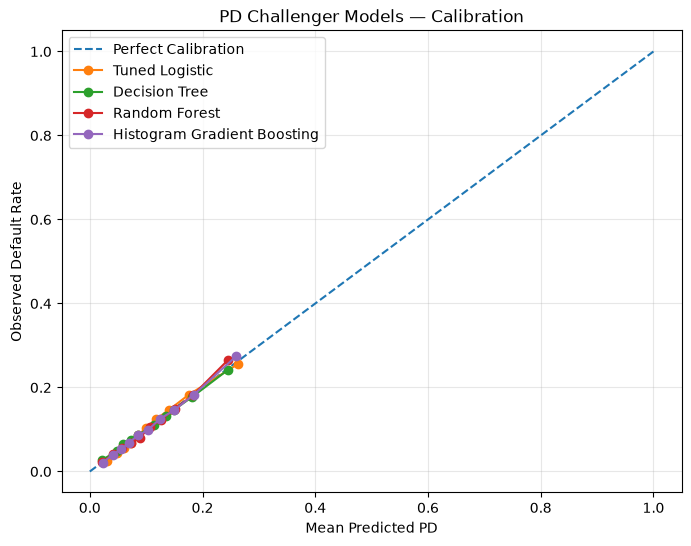

In [35]:
# -----------------------------------------------------------------------------
# Challenger calibration comparison
# -----------------------------------------------------------------------------

comparison_models = {
    "Tuned Logistic": best_logistic_model,
    "Decision Tree": best_decision_tree,
    "Random Forest": best_random_forest,
    "Histogram Gradient Boosting": best_hist_gradient_boosting,
}

plt.figure(
    figsize=(8, 6)
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration",
)

for model_name, model in comparison_models.items():

    y_val_proba = model.predict_proba(
        X_val
    )[:, 1]

    observed_rate, predicted_pd = calibration_curve(
        y_val,
        y_val_proba,
        n_bins=10,
        strategy="quantile",
    )

    plt.plot(
        predicted_pd,
        observed_rate,
        marker="o",
        label=model_name,
    )

plt.xlabel("Mean Predicted PD")
plt.ylabel("Observed Default Rate")

plt.title(
    "PD Challenger Models — Calibration"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [36]:
# -----------------------------------------------------------------------------
# Selected validation champion
# -----------------------------------------------------------------------------

best_validation_model = (
    challenger_comparison.iloc[0]
)

print("SELECTED PD CHAMPION")
print("=" * 60)
print(f"Model       : {best_validation_model['Model']}")
print(f"ROC-AUC     : {best_validation_model['ROC-AUC']:.4f}")
print(f"Gini        : {best_validation_model['Gini']:.4f}")
print(f"KS          : {best_validation_model['KS']:.4f}")
print(f"Brier Score : {best_validation_model['Brier Score']:.4f}")
print(f"Log Loss    : {best_validation_model['Log Loss']:.4f}")
print("=" * 60)

SELECTED PD CHAMPION
Model       : Histogram Gradient Boosting
ROC-AUC     : 0.7055
Gini        : 0.4110
KS          : 0.2995
Brier Score : 0.0918
Log Loss    : 0.3182


# 6. Final PD Model

Based on the common validation comparison, Histogram Gradient Boosting is
selected as the final PD champion.

It provides the strongest validation discrimination while maintaining good
probability quality and calibration.

The selected model specification is now frozen. No additional model selection
or hyperparameter tuning is performed after this point.

The champion is refitted on the complete development sample and evaluated once
on the untouched external test sample.

## 6.1 Final Model Refit

The selected Histogram Gradient Boosting model is refitted on the complete
development sample using the frozen hyperparameter configuration identified
during cross-validation.

No additional tuning or model selection is performed. The external test sample
remains untouched during this step.

In [37]:
# =============================================================================
# 6.1 Final Model Refit
# =============================================================================

CHAMPION_NAME = "Histogram Gradient Boosting"

final_pd_model = clone(
    best_hist_gradient_boosting
)

print("Final PD Model Refit")
print("=" * 60)
print(f"Champion      : {CHAMPION_NAME}")
print(f"Training rows : {len(X_train_encoded):,}")
print(f"Parameters    : {best_hist_gradient_boosting_params}")
print("=" * 60)

start_time = perf_counter()

final_pd_model.fit(
    X_train_encoded,
    y_train,
)

elapsed_time = (
    perf_counter()
    - start_time
)

print(
    f"Completed in {elapsed_time:.1f} s"
)

Final PD Model Refit
Champion      : Histogram Gradient Boosting
Training rows : 373,028
Parameters    : {'l2_regularization': 1.0, 'learning_rate': 0.05, 'max_iter': 200, 'max_leaf_nodes': 31, 'min_samples_leaf': 500}
Completed in 33.9 s


## 6.2 Final Performance Summary

The refitted champion is evaluated once on the untouched test sample.

Performance stability is assessed across cross-validation, validation and test
results using discrimination and probability-quality metrics. Final test
calibration is also examined by comparing predicted PDs with observed default
rates.

The test results are used for reporting only and do not trigger any additional
model selection or tuning.

In [49]:
# =============================================================================
# 6.2 Final Performance Summary
# =============================================================================

# -----------------------------------------------------------------------------
# Final test evaluation
# -----------------------------------------------------------------------------

final_test_results = evaluate_pd_model(
    model=final_pd_model,
    X=X_test_encoded,
    y=y_test,
)


# -----------------------------------------------------------------------------
# Final performance summary
# -----------------------------------------------------------------------------

final_performance_summary = pd.DataFrame(
    {
        "Stage": [
            "Cross-Validation",
            "Validation",
            "Test",
        ],
        "ROC-AUC": [
            best_hgb_cv_auc,
            hist_gradient_boosting_validation_results.loc[0, "ROC-AUC"],
            final_test_results.loc[0, "ROC-AUC"],
        ],
        "Gini": [
            np.nan,
            hist_gradient_boosting_validation_results.loc[0, "Gini"],
            final_test_results.loc[0, "Gini"],
        ],
        "KS": [
            np.nan,
            hist_gradient_boosting_validation_results.loc[0, "KS"],
            final_test_results.loc[0, "KS"],
        ],
        "Brier Score": [
            best_hgb_cv_brier,
            hist_gradient_boosting_validation_results.loc[0, "Brier Score"],
            final_test_results.loc[0, "Brier Score"],
        ],
        "Log Loss": [
            best_hgb_cv_log_loss,
            hist_gradient_boosting_validation_results.loc[0, "Log Loss"],
            final_test_results.loc[0, "Log Loss"],
        ],
        "Mean Predicted PD": [
            np.nan,
            hist_gradient_boosting_validation_results.loc[
                0, "Mean Predicted PD"
            ],
            final_test_results.loc[
                0, "Mean Predicted PD"
            ],
        ],
        "Observed Default Rate": [
            np.nan,
            hist_gradient_boosting_validation_results.loc[
                0, "Observed Default Rate"
            ],
            final_test_results.loc[
                0, "Observed Default Rate"
            ],
        ],
    }
)

final_performance_summary["Calibration Gap"] = (
    final_performance_summary["Mean Predicted PD"]
    - final_performance_summary["Observed Default Rate"]
)

print("FINAL PD MODEL PERFORMANCE")
print("=" * 70)

display(
    final_performance_summary.round(4)
)

FINAL PD MODEL PERFORMANCE


,Stage,ROC-AUC,Gini,KS,Brier Score,Log Loss,Mean Predicted PD,Observed Default Rate,Calibration Gap
0,Cross-Validation,0.7035,NaN,NaN,0.0921,0.3189,NaN,NaN,NaN
1,Validation,0.7055,0.4110,0.2995,0.0918,0.3182,0.1093,0.1093,-0.0000
2,Test,0.7020,0.4039,0.2973,0.0920,0.3191,0.1091,0.1093,-0.0002


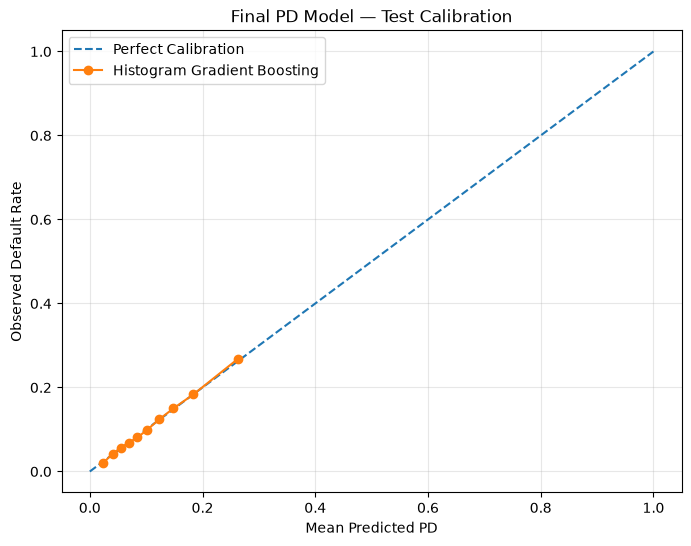

In [50]:
# =============================================================================
# 6.2 Final Test Calibration
# =============================================================================

y_test_proba = final_pd_model.predict_proba(
    X_test_encoded
)[:, 1]

observed_rate, predicted_pd = calibration_curve(
    y_test,
    y_test_proba,
    n_bins=10,
    strategy="quantile",
)

plt.figure(
    figsize=(8, 6)
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration",
)

plt.plot(
    predicted_pd,
    observed_rate,
    marker="o",
    label=CHAMPION_NAME,
)

plt.xlabel("Mean Predicted PD")
plt.ylabel("Observed Default Rate")
plt.title("Final PD Model — Test Calibration")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [51]:
# =============================================================================
# 6.4 Final Model Export
# =============================================================================

final_artifacts = save_final_pd_artifacts(
    model=final_pd_model,
    performance_summary=final_performance_summary,
    model_dir=MODEL_DIR,
)

print("Final PD Model Export")
print("=" * 60)
print(f"Champion    : {CHAMPION_NAME}")
print(f"Model       : {final_artifacts['model_path']}")
print(f"Performance : {final_artifacts['performance_path']}")
print("=" * 60)

Final PD Model Export
Champion    : Histogram Gradient Boosting
Model       : C:\Users\htouy\OneDrive - HEC Montréal\Bureau\GitHub\risk-credit-scoring-new\models\pd\final_pd_model.joblib
Performance : C:\Users\htouy\OneDrive - HEC Montréal\Bureau\GitHub\risk-credit-scoring-new\models\pd\final_pd_performance.csv


In [2]:
print(final_pd_model.classes_)

NameError: name 'final_pd_model' is not defined